## Trend Lines — Walkback

Walk **backward** from the last bar, maintaining a stack of candidate trendline legs (A–B, B–C, C–D, …). Geometrically the stack is the convex hull of the bars walked so far (built right-to-left, incrementally), so every leg's line clears every walked bar — each leg is a genuine two-touch trendline. The walk is governed by three pluggable heuristics:

1. **stop_continue** — a new point *below* the last leg: keep walking? (trivial default: stop after `max_bars`; later: gap-over-patience).
2. **stop_folding** — a new point *above* the last leg proposes a **fold** (pop the last vertex). Gate it: if the folded leg would fly too far above the tail it is a regime-crossing jump — reject the fold and stop. The pre-fold stack survives intact.
3. **eval_leg** — after the stop, score every leg in the stack (leg length x coverage) and pick the winner.

The window is an *output*: the walk runs exactly as far back as the trend structure supports. Coverage is cheap — the average gap between a line and the prices is just `line(mid) - mean(price)` (difference of averages), i.e. the `sad` measure per bar.

> **Status: EXPERIMENTAL — mirrored in `src/mplchart/primitives/trendlines.py`.**
> The engine cell and the `TrendLines` primitive cell below are copied verbatim into that module (imports adjusted to relative form), which exports `TrendLines` via `mplchart.primitives`. This notebook is the lab: iterate here (the local definitions shadow the installed ones), and when a change stabilizes, copy the two cells' contents back into the module and rerun `pytest`. The primitive's heuristics, parameters, and output contract are likely to change — do not build on them yet.

In [1]:
import numpy as np
import yfinance as yf

from mplchart.chart import Chart
from mplchart.primitives import Candlesticks
from mplchart.utils import normalize_prices

In [2]:
ticker = "AAPL"
prices = normalize_prices(yf.Ticker(ticker).history(period="5y"))
prices = prices.iloc[:-700]
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 555 entries, 2021-07-22 00:00:00-04:00 to 2023-10-04 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   open          555 non-null    float64
 1   high          555 non-null    float64
 2   low           555 non-null    float64
 3   close         555 non-null    float64
 4   volume        555 non-null    int64  
 5   dividends     555 non-null    float64
 6   stock splits  555 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 34.7 KB


In [3]:
# EXPERIMENTAL — mirrored in src/mplchart/primitives/trendlines.py; keep in sync
from typing import Callable, NamedTuple, TypedDict

from numpy.lib.stride_tricks import sliding_window_view

# The two sides. Client code uses the names, never the values — that the
# constants double as the direction multiplier is an implementation
# detail of the geometry below.
SUPPORT = -1
RESISTANCE = +1

# Hook contracts — the walk calls these; the factories below build them.
# A stop hook returns None to proceed or a reason string to stop.
StopHook = Callable[[int, list[int], np.ndarray, int], str | None]  # (i, stack, y, side)
EvalLeg = Callable[[np.ndarray, int, int, int], float]  # (y, i1, i2, side)


class WalkParams(TypedDict, total=False):
    """Typed parameter bundle for walk_side / trend_lines / TrendLines."""

    span: int
    max_gap: float
    max_bars: int
    max_legs: int


# Default walk parameters — the single source of truth; every entry point
# (heuristic factories, walk_side, TrendLines) defaults to these.
# Zero disables a knob (same convention as span=0).
DEFAULT_SPAN: int = 5
DEFAULT_MAX_GAP: float = 6.0
DEFAULT_MAX_BARS: int = 250
DEFAULT_MAX_LEGS: int = 0


def leg_line(y, i1, i2):
    """(slope, intercept) of the line through bars i1 and i2 of y."""
    m = (y[i2] - y[i1]) / (i2 - i1)
    return m, y[i1] - m * i1


def avg_move(y, lo=0):
    """Per-bar scale of y over bars lo..end: the mean absolute one-bar
    change — the close-to-close cousin of the daily trading range.
    Local to the surveyed range, so old structure is measured in its own
    era's units. Built on changes, not levels (level-stdev is inflated
    by trends and regime jumps), and robust to a few outlier bars."""
    d = np.diff(y[lo:])
    return float(np.abs(d).mean()) if len(d) else 1.0


def avg_gap(y, i1, i2, lo, side=RESISTANCE):
    """Average distance between the line through (i1, i2) and y over bars
    lo..end, in units of the range's own average move — oriented so a
    valid line reads positive on either side. The line is linear, so its
    average over the range is its value at the range midpoint — a
    difference of averages."""
    m, b = leg_line(y, i1, i2)
    mid = (lo + len(y) - 1) / 2
    return float(side * (m * mid + b - y[lo:].mean()) / avg_move(y, lo))


def local_extrema(y, span, side=RESISTANCE):
    """Indices of the swings of y: bars that are the extremum within
    +/- span bars, with span real bars on each side. One parameter
    governs the whole definition — a bar near the edges (including the
    last bars) is not a swing until span bars exist beyond it.
    RESISTANCE finds peaks, SUPPORT valleys."""
    z = y * side  # comparisons only — heuristics never see this
    window = 2 * span + 1
    rolling = sliding_window_view(z, window).max(axis=1)
    return np.where(z[span:-span] == rolling)[0] + span


def walkback(y, *, stop_continue: StopHook, stop_folding: StopHook,
             span: int = 0, side: int = RESISTANCE):
    """Backward hull walk over real prices.

    side: RESISTANCE fits a line above the highs, SUPPORT a line below
    the lows. The heuristics always receive the actual prices — the
    side is a parameter, not a data transform.

    span: swing filter width. With span > 0, only swings (local extrema
    within +/- span bars, span bars on each side) are touch points, and
    the walk anchors at the most recent swing instead of the last bar.
    Legs then clear every swing, and brief pokes by non-swing bars are
    tolerated — this kills single-bar staircase legs and wick noise.
    The quality heuristics still measure coverage against all bars.
    span=0 is the degenerate case: every bar is a touch point and the
    walk anchors at the last bar.

    Returns (stack, origin, reason): hull vertex indices newest-first,
    the oldest bar still covered, and the reason the walk ended.
    """
    n = len(y)
    if span > 0:
        points = [int(i) for i in local_extrema(y, span, side)[::-1]]
        anchor = points.pop(0) if points else n - 1
    else:
        points = range(n - 2, -1, -1)
        anchor = n - 1

    stack = [anchor]
    origin = anchor
    for i in points:
        # proposed folds — the new point pokes at or beyond the last leg
        while len(stack) >= 2:
            m, b = leg_line(y, stack[-2], stack[-1])
            if side * (y[i] - (m * i + b)) < 0:
                break
            if reason := stop_folding(i, stack, y, side):
                return stack, origin, reason
            stack.pop()
        if reason := stop_continue(i, stack, y, side):
            return stack, origin, reason
        stack.append(i)
        origin = i
    return stack, origin, "data exhausted"


# --- the three heuristics, trivial defaults, refine as we go ---

def make_stop_continue(max_bars: int = DEFAULT_MAX_BARS,
                       max_legs: int = DEFAULT_MAX_LEGS) -> StopHook:
    """1. point inside the last leg: keep walking?

    Two trivial conditions with different semantics: max_bars bounds
    time (safety net), max_legs bounds structural richness — stop once
    the stack holds enough candidate timescales to choose from. Depth
    is not monotone (folds shrink it), so max_legs alone does not
    guarantee termination; keep max_bars alongside it.
    """
    def stop_continue(i: int, stack: list[int], y: np.ndarray, side: int) -> str | None:
        if max_legs > 0 and len(stack) - 1 >= max_legs:
            return "leg budget"
        if len(y) - 1 - i > max_bars:
            return "max bars"
        return None
    return stop_continue


def make_stop_folding(max_gap: float = DEFAULT_MAX_GAP) -> StopHook:
    """2. proposed fold: reject it when the folded leg (stack[-2] -> i)
    would sit more than max_gap average moves away from the tail it
    must cover. max_gap=0 disables the gate — every fold is accepted."""
    def stop_folding(i: int, stack: list[int], y: np.ndarray, side: int) -> str | None:
        if max_gap > 0 and avg_gap(y, stack[-2], i, i, side) > max_gap:
            return "fold rejected"
        return None
    return stop_folding


def make_eval_leg() -> EvalLeg:
    """3. candidate quality: leg span, discounted by how far the line
    sits from the prices over the stretch it serves (old touch to now)."""
    def eval_leg(y: np.ndarray, i1: int, i2: int, side: int) -> float:
        span = i1 - i2
        gap = avg_gap(y, i1, i2, i2, side)
        return span / (1.0 + gap)
    return eval_leg


def select_leg(stack, y, eval_leg: EvalLeg, side: int = RESISTANCE):
    """Score every leg in the stack, return (legs, scores, winner index)."""
    legs = list(zip(stack, stack[1:]))
    scores = [eval_leg(y, i1, i2, side) for i1, i2 in legs]
    return legs, scores, int(np.argmax(scores))


# --- drivers — the debugging entry points; the primitive calls these ---

class WalkResult(NamedTuple):
    """Scored outcome of one walkback side."""

    legs: list[tuple[int, int]]
    scores: list[float]
    gaps: list[float]
    win: int
    origin: int
    reason: str


def walk_side(y, *, side: int = RESISTANCE, span: int = DEFAULT_SPAN,
              max_gap: float = DEFAULT_MAX_GAP,
              max_bars: int = DEFAULT_MAX_BARS,
              max_legs: int = DEFAULT_MAX_LEGS) -> WalkResult:
    """Run one walkback side on real prices and score the legs.

    side=RESISTANCE walks the highs, side=SUPPORT walks the lows.
    """
    stop_continue = make_stop_continue(max_bars=max_bars, max_legs=max_legs)
    stop_folding = make_stop_folding(max_gap=max_gap)
    eval_leg = make_eval_leg()

    stack, origin, reason = walkback(
        y, stop_continue=stop_continue, stop_folding=stop_folding, span=span, side=side
    )
    legs, scores, win = select_leg(stack, y, eval_leg, side)
    gaps = [avg_gap(y, i1, i2, i2, side) for i1, i2 in legs]
    return WalkResult(legs, scores, gaps, win, origin, reason)


def trend_lines(high, low, **params) -> dict[str, WalkResult]:
    """Both sides on raw high/low arrays. Returns {name: WalkResult}.

    params: see WalkParams (span, max_gap, max_bars, max_legs).
    """
    return {
        "support": walk_side(low, side=SUPPORT, **params),
        "resistance": walk_side(high, side=RESISTANCE, **params),
    }

In [4]:
# EXPERIMENTAL — mirrored in src/mplchart/primitives/trendlines.py; keep in sync
from mplchart.model.primitive import Primitive
from mplchart.utils import col_to_numpy


class TrendLines(Primitive):
    """Walkback trendlines: a support and a resistance ladder per chart.

    Thin drawing wrapper over ``trend_lines`` — run that function on raw
    high/low arrays for debugging. Draws the ladder: the winning leg and
    the runner-ups newer than it extend to now; older legs stop at their
    arrival point. Touch points are marked.

    Args:
        span: swing filter width — only swings (extrema within +/- span
            bars, with span bars on each side) qualify as touch points.
            span=0 degrades to the raw walk: every bar is a touch point,
            anchored at the last bar.
        max_gap: fold-gate horizon knob, in average moves (avg_move over
            the surveyed range). A fold bridging structure further away
            from the tail is rejected and the walk stops at the regime
            boundary. 0 disables the gate.
        max_bars: time safety net for the walk.
        max_legs: leg budget — stop once the stack holds this many legs
            (peak depth runs ~9-12 empirically, 17 max). 0 disables.
        colors: (support, resistance) line colors.
    """

    def __init__(self, span: int = DEFAULT_SPAN, *,
                 max_gap: float = DEFAULT_MAX_GAP,
                 max_bars: int = DEFAULT_MAX_BARS,
                 max_legs: int = DEFAULT_MAX_LEGS,
                 colors: tuple[str, str] = ("green", "red")):
        self.span = span
        self.max_gap = max_gap
        self.max_bars = max_bars
        self.max_legs = max_legs
        self.colors = colors

    def apply_to_chart(self, chart):
        ax = chart.canvas.get_axes()
        prices = chart.view.prices
        high = np.asarray(col_to_numpy(prices, "high"), dtype=float)
        low = np.asarray(col_to_numpy(prices, "low"), dtype=float)

        results = trend_lines(
            high, low, span=self.span, max_gap=self.max_gap,
            max_bars=self.max_bars, max_legs=self.max_legs,
        )

        for (name, result), color in zip(results.items(), self.colors):
            y = low if name == "support" else high
            self._draw_side(chart, ax, y, result, color, name)

    def _draw_side(self, chart, ax, y, result, color, label):
        n = len(y)
        for k, (i1, i2) in enumerate(result.legs):
            m, b = leg_line(y, i1, i2)
            # winner and newer legs extend to now; older stop at arrival
            hi = n if k <= result.win else i1 + 1
            vals = np.full(n, np.nan)
            vals[i2:hi] = m * np.arange(i2, hi) + b
            xs, vv = chart.view.series_xy(vals)
            if k == result.win:
                ax.plot(xs, vv, color=color, linewidth=1.8, label=label)
            else:
                ax.plot(xs, vv, color=color, linewidth=1.0, alpha=0.3)

            marks = np.full(n, np.nan)
            marks[[i1, i2]] = y[[i1, i2]]
            xm, vm = chart.view.series_xy(marks)
            ax.scatter(xm, vm, color=color, s=25, alpha=0.6)

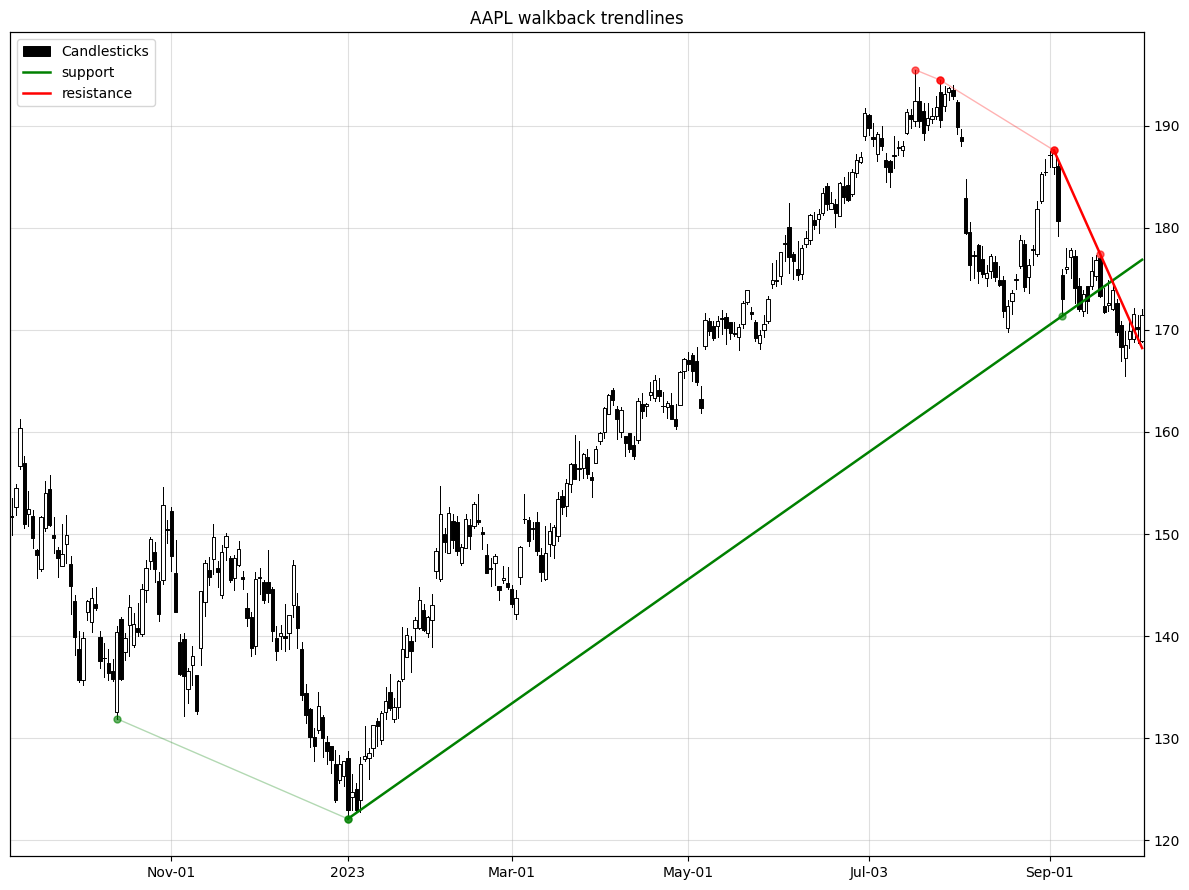

In [5]:
max_bars = 250
params = WalkParams(span=5, max_gap=0, max_bars=max_bars)

chart = Chart(prices, title=f"{ticker} walkback trendlines", max_bars=max_bars + 20)
chart.plot(Candlesticks(), TrendLines(**params))
chart.show()

In [6]:
# debugging path: run the walk directly on the data
results = trend_lines(prices["high"].to_numpy(), prices["low"].to_numpy(), **params)

for name, r in results.items():
    print(f"{name}: {len(r.legs)} legs, stop: {r.reason} at bar {r.origin}")
    for k, ((i1, i2), score, gap) in enumerate(zip(r.legs, r.scores, r.gaps)):
        mark = " <- winner" if k == r.win else ""
        print(f"  leg {i1}-{i2}: span={i1 - i2:3d}  gap={gap:5.2f} moves  score={score:6.1f}{mark}")

support: 2 legs, stop: max bars at bar 310
  leg 535-365: span=170  gap=10.20 moves  score=  15.2 <- winner
  leg 365-310: span= 55  gap=28.85 moves  score=   1.8
resistance: 3 legs, stop: max bars at bar 305
  leg 544-533: span= 11  gap= 1.43 moves  score=   4.5 <- winner
  leg 533-506: span= 27  gap= 5.56 moves  score=   4.1
  leg 506-500: span=  6  gap= 6.44 moves  score=   0.8


### Notes

- The stack at stop time is the hull of the *adaptive* window — a batch convex-hull construction plus automatic window selection plus leg scoring. The faded lines are the runner-up candidates: competing trendlines at different time scales, exactly the walkback thought experiment.
- **The fold gate is the horizon knob.** With the gate on, the stop lands on the last regime boundary (e.g. a crash cliff) and is insensitive to the exact threshold below the cliff height — the structure decides, not the knob. With `max_gap=0` the walk runs to `max_bars` and the winner tends to be a long structural leg that bridges regimes. Both are legitimate answers to different questions.
- **Leg depth is intrinsically small.** Simulated on AAPL/SPY (10y, ungated, 300 anchors): final depth median 5-6, peak depth median 9-12, absolute max 17 — consistent with the O(log n) hull size of random-walk-like paths. `max_legs` in the 16-20 range is a never-binding backstop; 6-8 stops actively, but tends to freeze pre-fold staircases that the next fold would have collapsed. (The original A-B-C trio is this walk with `max_legs=2`.)
- **Scale is local, not global.** Gaps are measured in average moves — the mean absolute one-bar change over the surveyed range (`avg_move`, the close-to-close cousin of the daily trading range) — so each test is scaled by the era it measures and no ATR constant is threaded through the API. Changes, not levels: level-stdev is inflated by trends and regime jumps, which would neuter the fold gate exactly at cliffs. Walking log prices would make the measure fully relative (return units) — a natural later experiment.
- After a rejected fold, the winning line is a resistance for its own regime only — the rejected older spike is above it, by design. The output contract is `(slope, intercept, origin)`: the line plus its validity span.
- Refinement ideas, one hook at a time:
  - `stop_continue`: replace `max_bars` with patience — stop when the gap to the last leg exceeds `g` average moves for more than `L` consecutive bars.
  - `stop_folding`: add a length term (a fold reaching far back needs proportionally better coverage), or compare the folded leg's quality against the current best leg.
  - `eval_leg`: count touches within a `k`-move band instead of raw span; penalize legs whose two touches are close together relative to the stretch they serve.

### Walk-forward replay

Rerun the walk as of successively earlier dates: each chart truncates 50 more bars off the end of the same prices frame, starting from no truncation. Watching the winner change (or hold) across replays is a cheap stability check on the heuristics.

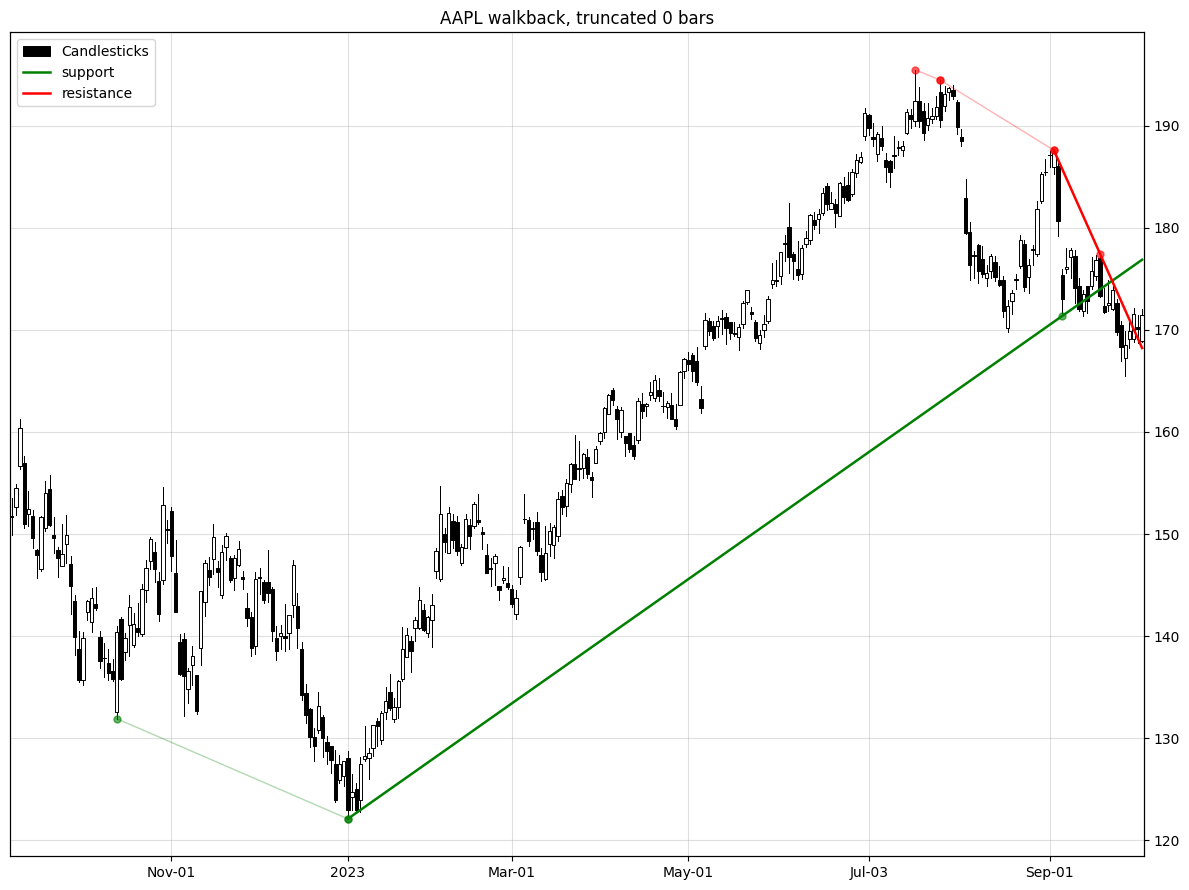

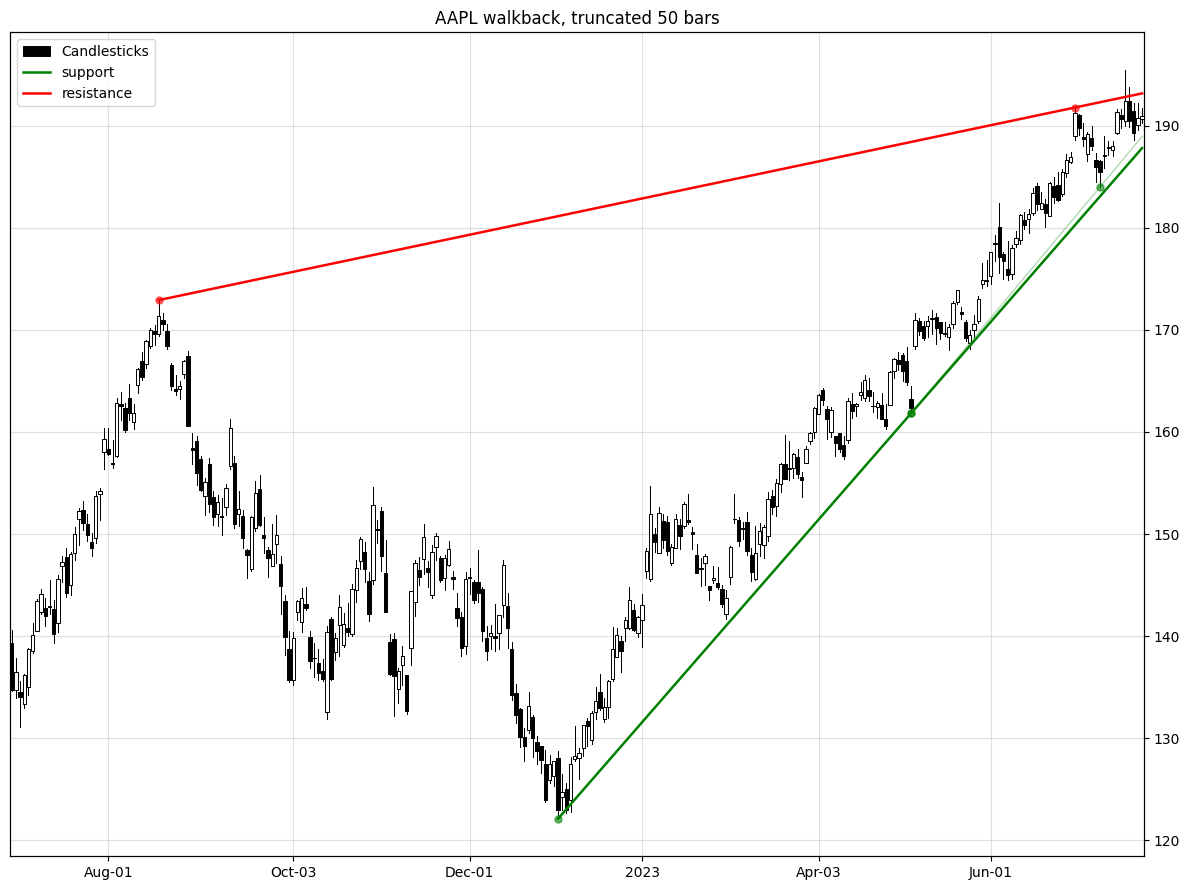

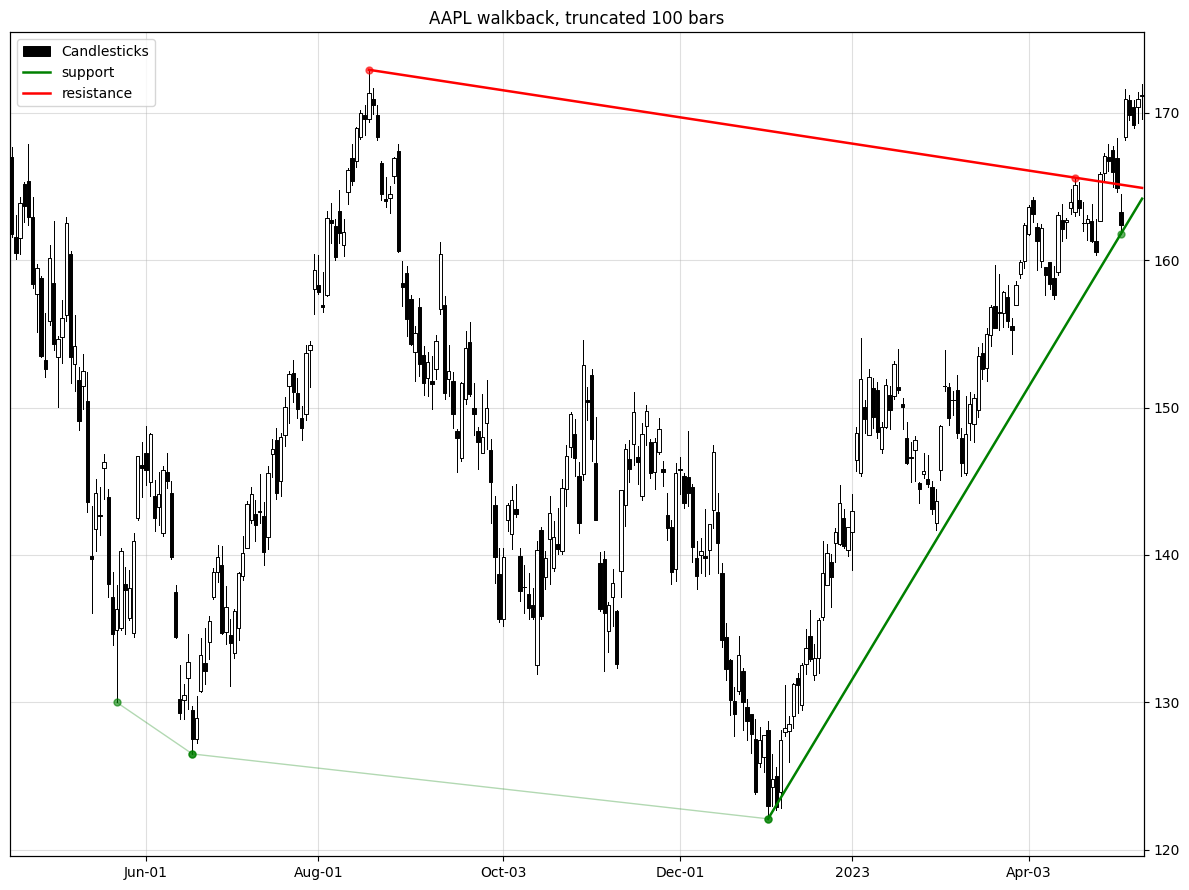

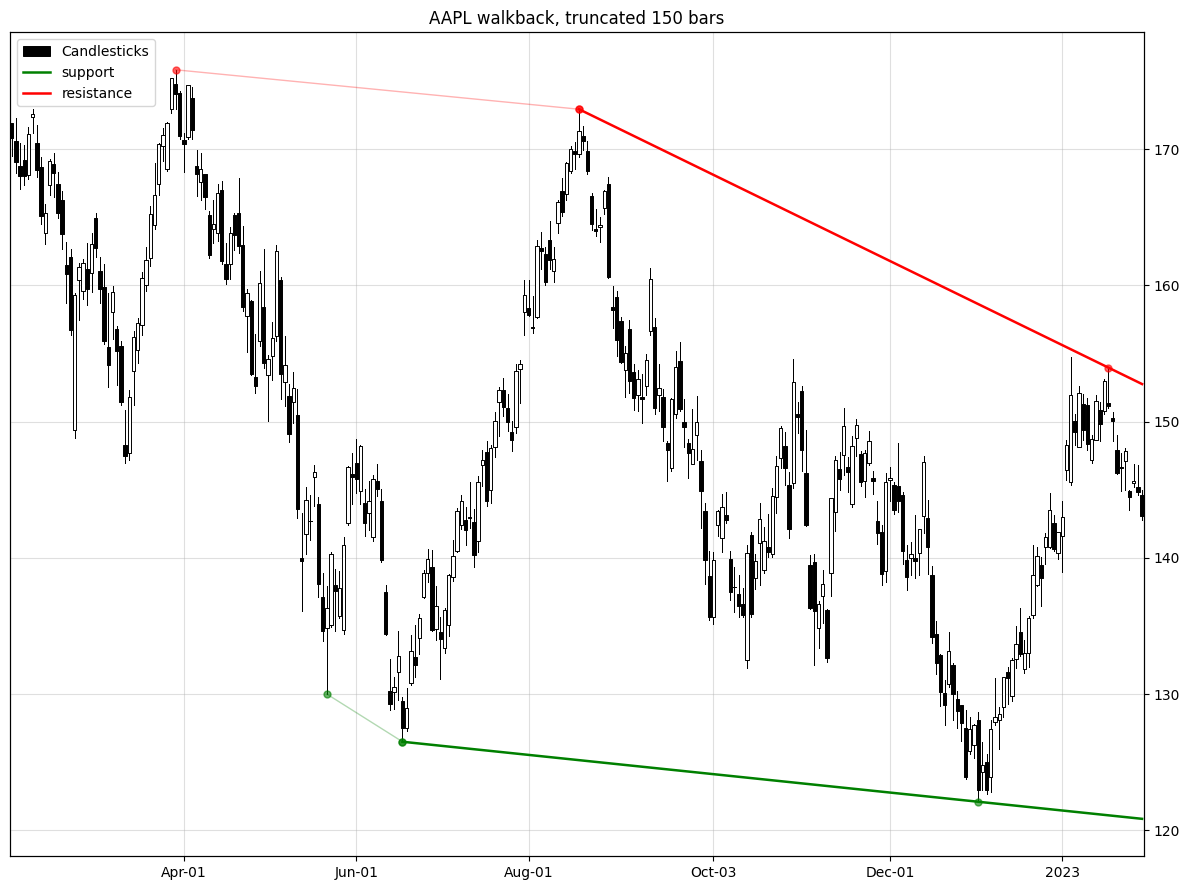

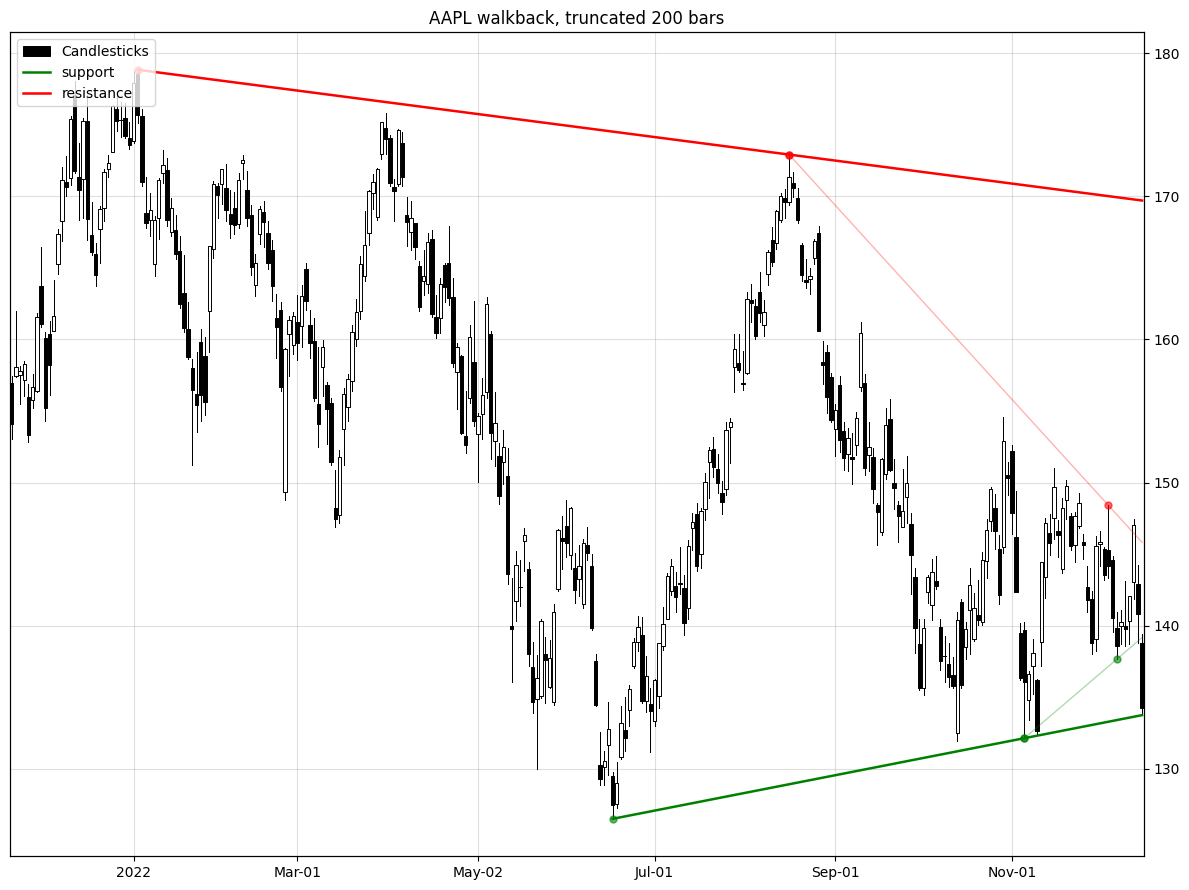

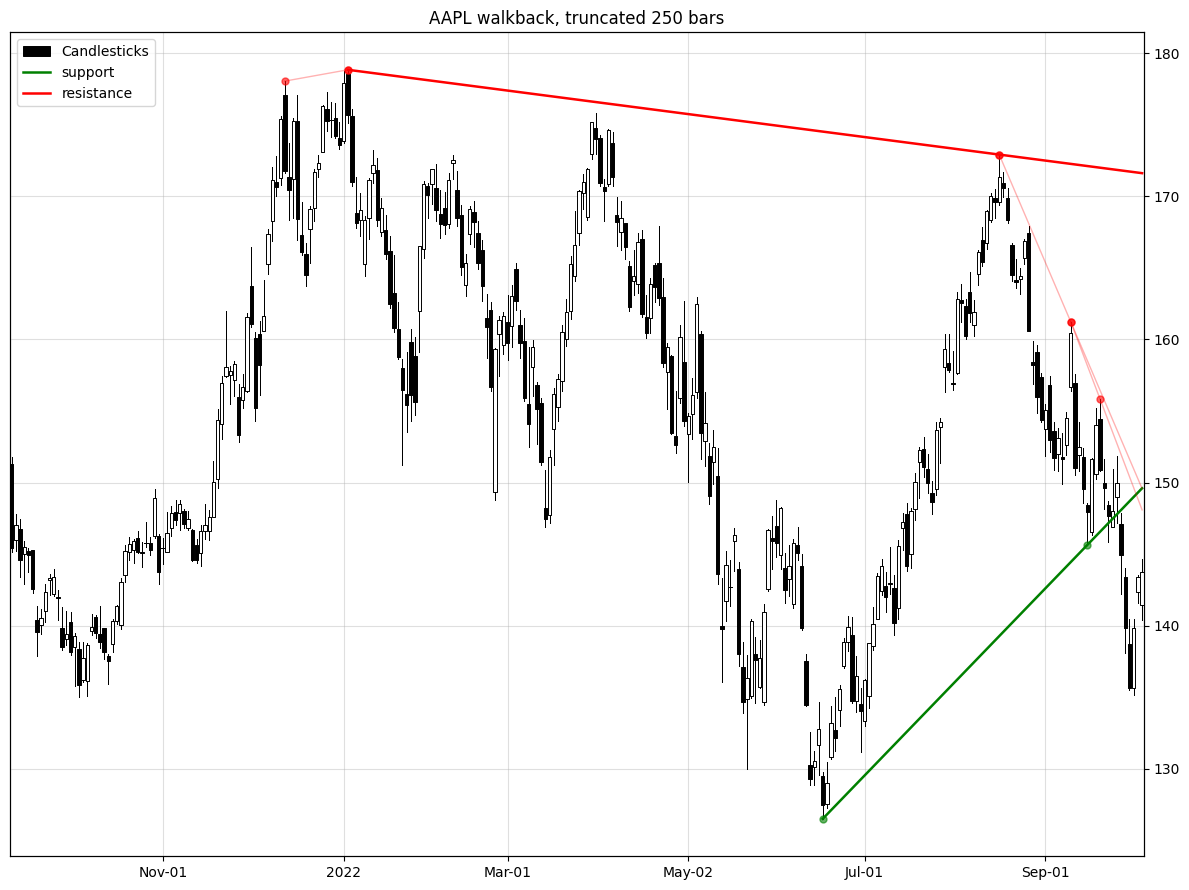

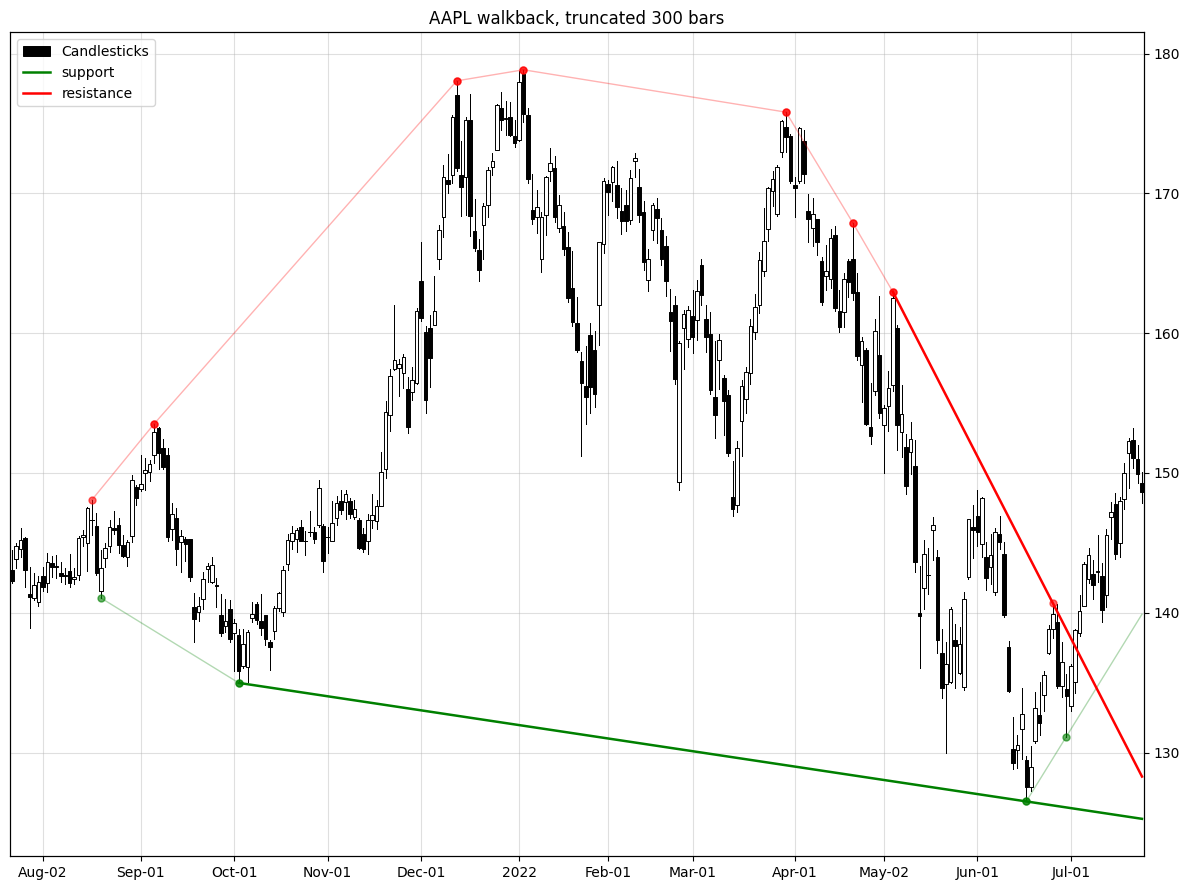

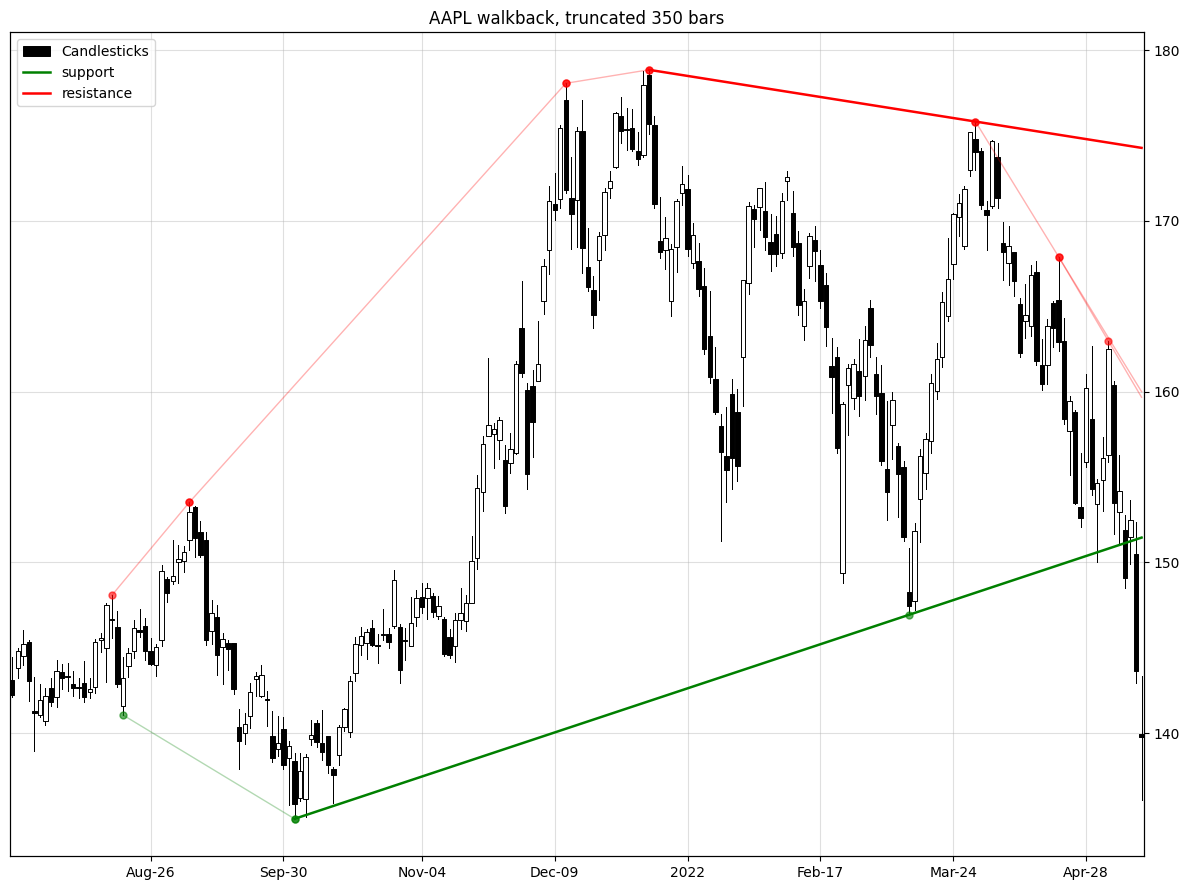

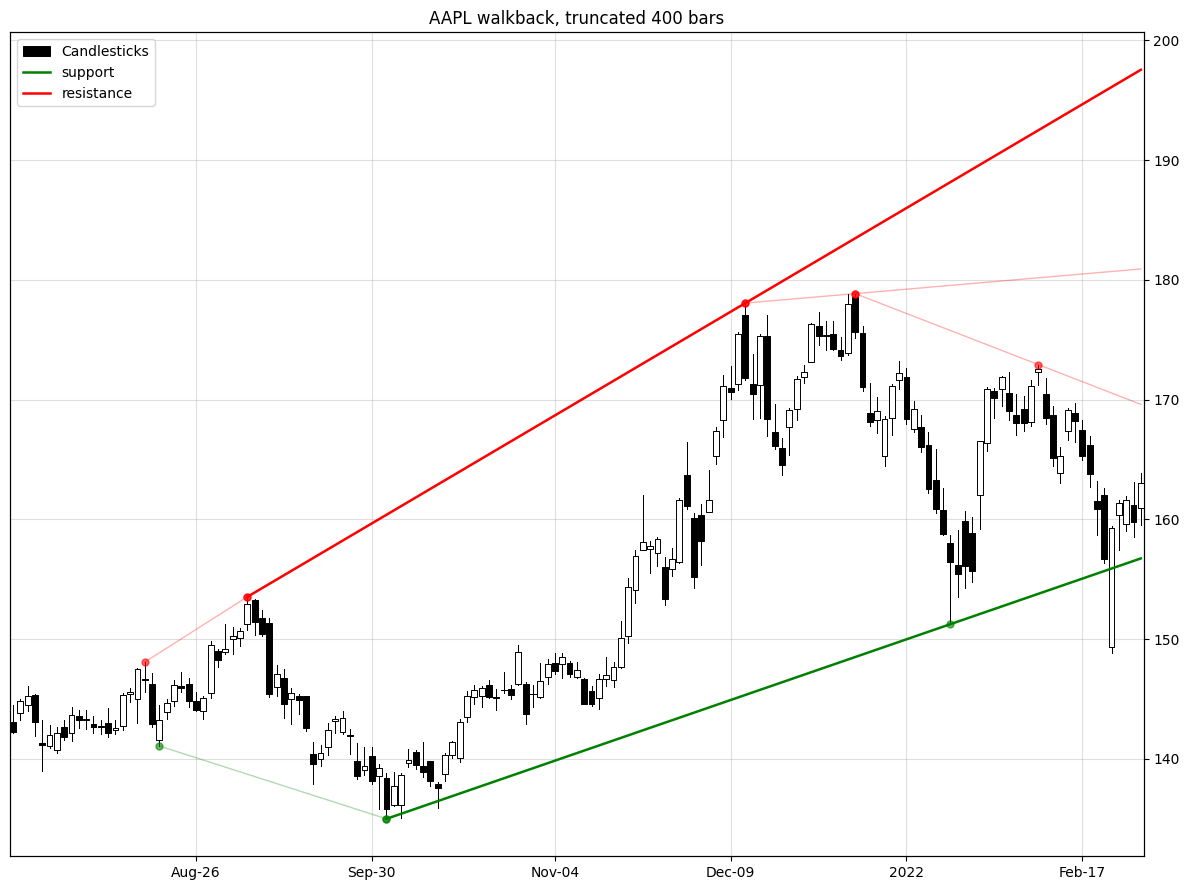

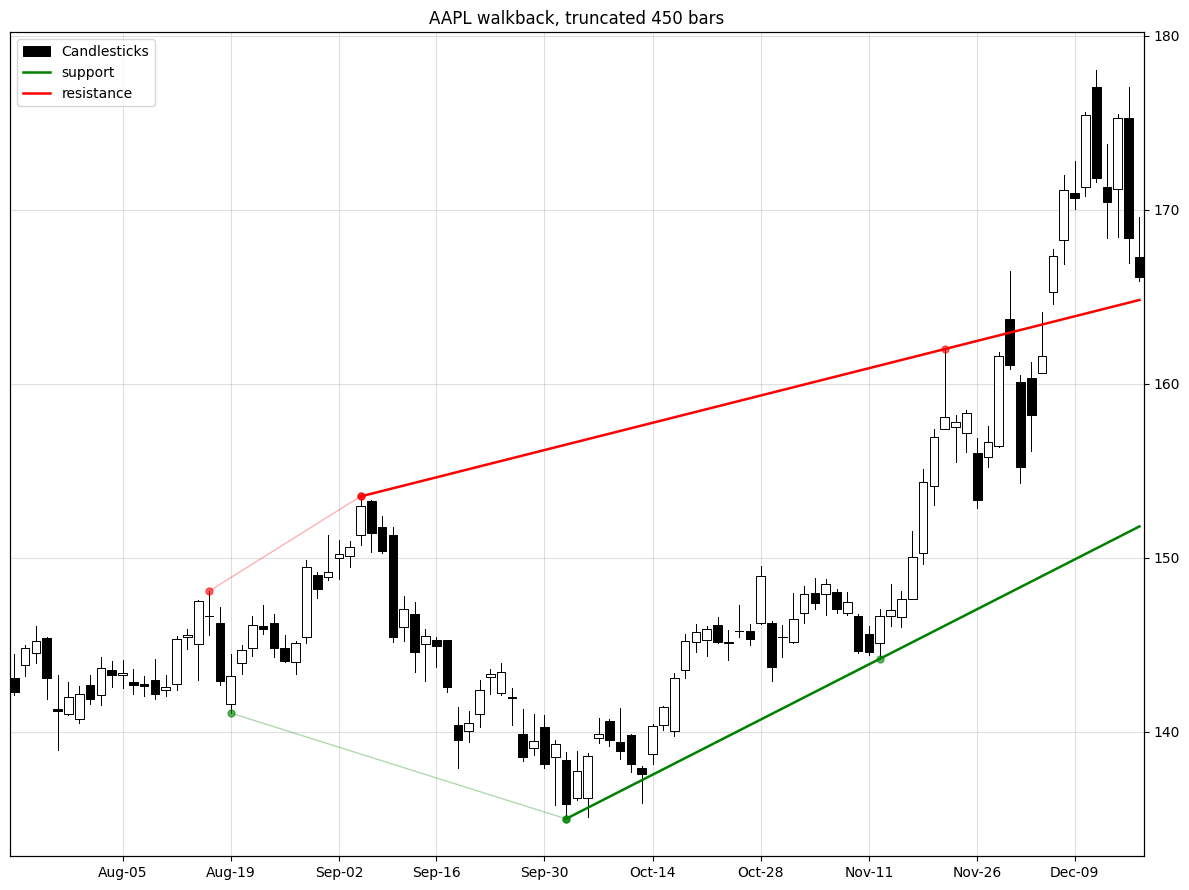

In [7]:
for k in range(10):
    cut = prices.iloc[:len(prices) - k * 50]
    if len(cut) < 50:
        break
    chart = Chart(cut, title=f"{ticker} walkback, truncated {k * 50} bars",
                  max_bars=max_bars + 20)
    chart.plot(Candlesticks(), TrendLines(**params))
    chart.show()